### Imports 

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from optic.models.tx import pamTransmitter
from optic.models.devices import photodiode, edfa, dac, adc, mzm, basicLaserModel
from optic.dsp.equalization import dfe, ffe
from optic.models.channels import linearFiberChannel, awgn
from optic.comm.sources import bitSource
from optic.comm.modulation import modulateGray, grayMapping , demodulateGray
from optic.comm.metrics import bert, fastBERcalc, theoryBER
from optic.dsp.core import firFilter, pulseShape, upsample, pnorm, anorm, decimate ,signalPower
from optic.utils import parameters, dBm2W, lin2dB
from optic.plot import eyediagram, pconst
from scipy.special import erfc
import optic.comm.modulation as mod
from numpy.random import normal
import pandas as pd
import sys
import os


sys.path.append(os.path.abspath(os.path.join('..')))

In [17]:
from AnalyticalSNR import (
    superGauss,
    SNR_Folding,
    SNR_DFE,
    SNR_FFE,
    calc_S_th,
    calc_S_th_opticompy,
    calc_S_shot,
    calc_S_shot_opticompy,
    calc_S_RIN,
    calc_S_RIN_opticompy,
    calc_S_ADC,
    calc_S_ADC_opticompy,
    calc_S_N,
    calculate_oma_outer,
    get_spectral_snr,
    ber_from_snr_m_pam
)

## Simple IMDD Transceiver Model 

![Texto Alternativo](images/model.png)


Average power of the modulated optical signal [mW]: 0.500 mW
Average power of the modulated optical signal [dBm]: -3.014 dBm


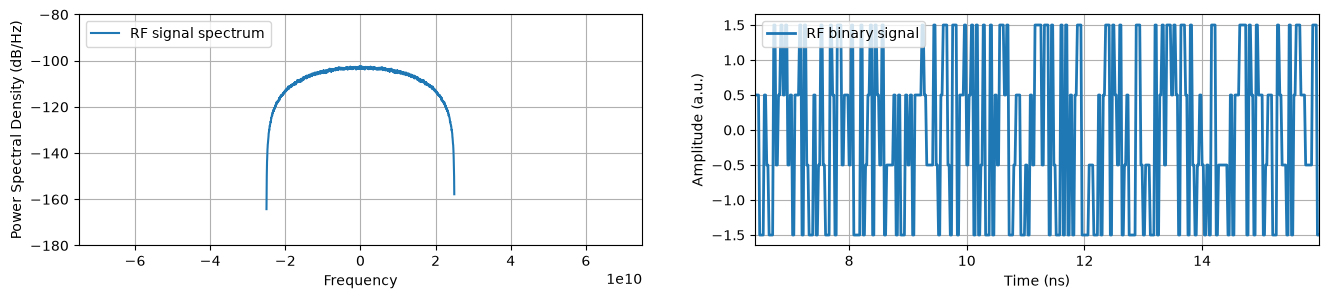

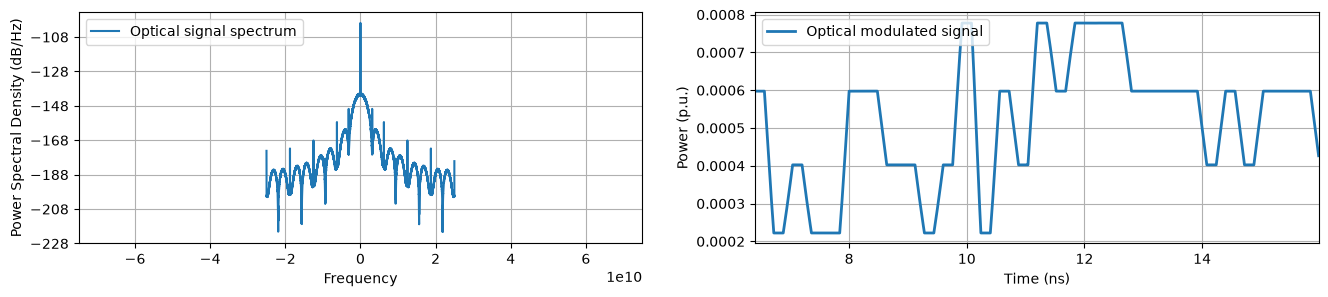

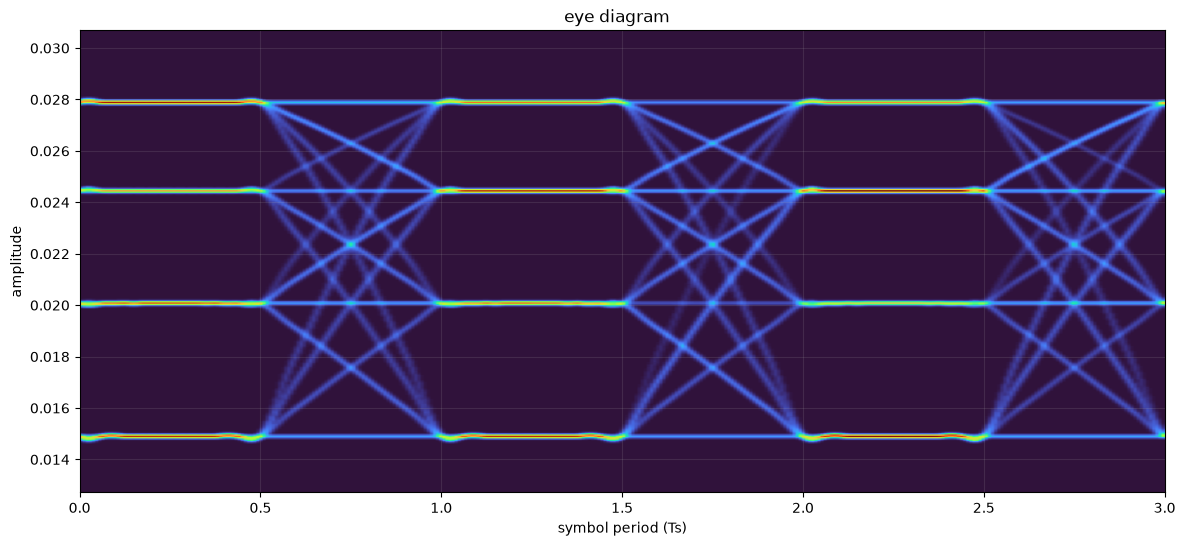

In [18]:
# Rate Sybol
Rs= 25e9

#Sample Per Symbol
SpS= 2

# Sample Rate
Fs= Rs*SpS
n_dac = 8

#Sample Time
Ts= 1/Fs

#Modulation Order
M= 4
Pi_dBm = 0         # laser optical power at the input of the MZM in dBm
Pi = dBm2W(Pi_dBm) # convert from dBm to W

#Parameters for Bits Generation
paramBits =  parameters()
paramBits.nBits = 500000
paramBits.mode= 'random'
paramBits.seed = 7
bits = bitSource(paramBits)

#Parameters for Modulation
symb_Tx= modulateGray(bits, M, 'pam')
symb_Tx_up = upsample(symb_Tx, SpS)

#Parameters for Pulse Shaping
paramPulse = parameters()
paramPulse.pulseType = 'rect'
paramPulse.SpS = SpS
pulse = pulseShape(paramPulse)

#Transmit Signal after Pulse Shaping
signal_Tx = firFilter(pulse, symb_Tx_up)

#DAC Parameters
paramDAC = parameters()
paramDAC.inFs = Fs            # Frequência de entrada (igual a Rs = 25e9)
paramDAC.outFs = n_dac*Fs        # Frequência de saída da simulação (Rs * SpS = 400e9)
paramDAC.nBits = 8         # Resolução nominal alta para emular DAC ideal
paramDAC.ENOB = 8           # Bits efetivos ideais (sem ruído térmico no DAC)
paramDAC.Vpp = 2*np.max(np.abs(signal_Tx))           # Tensão pico a pico elétrica normalizada
paramDAC.AIF = False         # Filtro Anti-Imagem desligado (evita filtro redundante)
signal_Tx_DAC = dac(signal_Tx, paramDAC)
#signal_Tx_DAC = signal_Tx

paramLaser = parameters()
paramLaser.P = Pi_dBm
paramLaser.lw = 0
paramLaser.RIN_var = 1e-14
paramLaser.Fs= paramDAC.outFs
paramLaser.Ns = len(signal_Tx_DAC)
laserTx = basicLaserModel(paramLaser)

paramMZM = parameters()
paramMZM.Vpi = 8
paramMZM.Vb= -paramMZM.Vpi/2

signal_optTx= mzm(laserTx, signal_Tx_DAC, paramMZM)


print('Average power of the modulated optical signal [mW]: %.3f mW'%(signalPower(signal_optTx)/1e-3))
print('Average power of the modulated optical signal [dBm]: %.3f dBm'%(10*np.log10(signalPower(signal_optTx)/1e-3)))


fig, axs = plt.subplots(1, 2, figsize=(16,3))
interval = np.arange(16*20,16*50)
t = interval*Ts/1e-9

# plot psd
axs[0].set_xlim(-3*Rs,3*Rs);
axs[0].set_ylim(-180,-80);
axs[0].psd(signal_Tx,Fs=Fs, NFFT = 2*1024, sides='twosided', label = 'RF signal spectrum')
axs[0].legend(loc='upper left');

axs[1].plot(t, signal_Tx[interval], label = 'RF binary signal', linewidth=2)
axs[1].set_ylabel('Amplitude (a.u.)')
axs[1].set_xlabel('Time (ns)')
axs[1].set_xlim(min(t),max(t))
axs[1].legend(loc='upper left')
axs[1].grid()

fig, axs = plt.subplots(1, 2, figsize=(16,3))
# plot psd
axs[0].set_xlim(-3*Rs,3*Rs);
axs[0].psd(signal_optTx, Fs=Fs, NFFT = 16*1024, sides='twosided', label = 'Optical signal spectrum')
axs[0].legend(loc='upper left');

axs[1].plot(t, np.abs(signal_optTx[interval])**2, label = 'Optical modulated signal', linewidth=2)
axs[1].set_ylabel('Power (p.u.)')
axs[1].set_xlabel('Time (ns)')
axs[1].set_xlim(min(t),max(t))
axs[1].legend(loc='upper left')
axs[1].grid()
plt.rcParams['figure.figsize'] = (14, 6)


eyediagram(np.real(signal_optTx), len(signal_optTx), n_dac*SpS ,ptype = 'fancy')

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def superGauss(f, n, B_3dB):
    '''
    Calculates the supergaussian filter frequency response for a given order n and 3dB bandwidth B_3dB.

    param:
        f (np.array): Frequency array (in Hz) for which to calculate the filter response.
        n (int): Order of the supergaussian filter.
        B_3dB (float): 3dB bandwidth of the filter (in Hz).
    
    return:
        H_sg (np.array): Frequency response of the supergaussian filter at the given frequencies.
    '''

    alpha = np.log(2)/2
    H_sg = np.exp(-alpha * (f / B_3dB)**(2*n))
    return H_sg

4000000


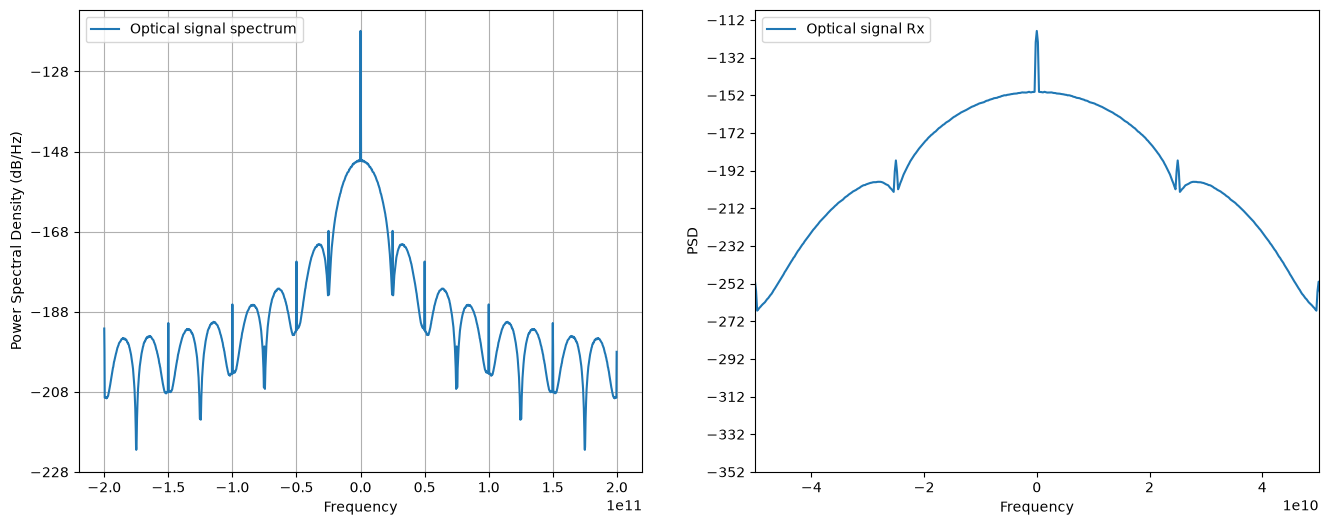

In [20]:
from scipy.fft import fft, ifft, fftfreq


# 1. Definir os parâmetros do canal baseados no artigo
# O artigo varia o B_3dB no eixo X dos gráficos (ex: de 0.1 a 1.5 * Rs)
# e testa a ordem do filtro como 1 e 3.
print(len(signal_optTx))
n_order = 1             # Ordem do supergaussiano (ex: 1 ou 3)
B_3dB = 0.4 * Rs        # Largura de banda em 40% da taxa de símbolos

# 2. Criar o vetor de frequências para o sinal de simulação
N_samples = len(signal_optTx)
sim_Fs = paramDAC.outFs # A taxa de amostragem do sinal modulado (400 GHz)

# Cria o vetor de frequências correspondente aos bins da FFT
f = fftfreq(N_samples, d=1/sim_Fs)

# 3. Gerar a resposta em frequência do canal
H_ch = superGauss(f, n_order, B_3dB)

# 4. Aplicar o filtro ao sinal no domínio da frequência
signal_optTx_fft = np.fft.fft(signal_optTx)
signal_optRx_fft = signal_optTx_fft * H_ch

# Retornar o sinal filtrado para o domínio do tempo
signal_optRx = ifft(signal_optRx_fft)

fig, axs = plt.subplots(1, 2, figsize=(16,6))
# plot psd
axs[0].psd(signal_optTx, Fs=paramDAC.outFs, NFFT = 2048, sides='twosided', label = 'Optical signal spectrum')
axs[0].legend(loc='upper left');

axs[1].psd(signal_optRx, Fs = paramDAC.outFs, NFFT = 2048, sides = 'twosided', label = "Optical signal Rx")
axs[1].set_ylabel('PSD')
axs[1].set_xlabel('Frequency')
axs[1].legend(loc='upper left')
axs[1].grid()
axs[1].set_xlim(-0.5e11, 0.5e11)
plt.rcParams['figure.figsize'] = (14, 6)



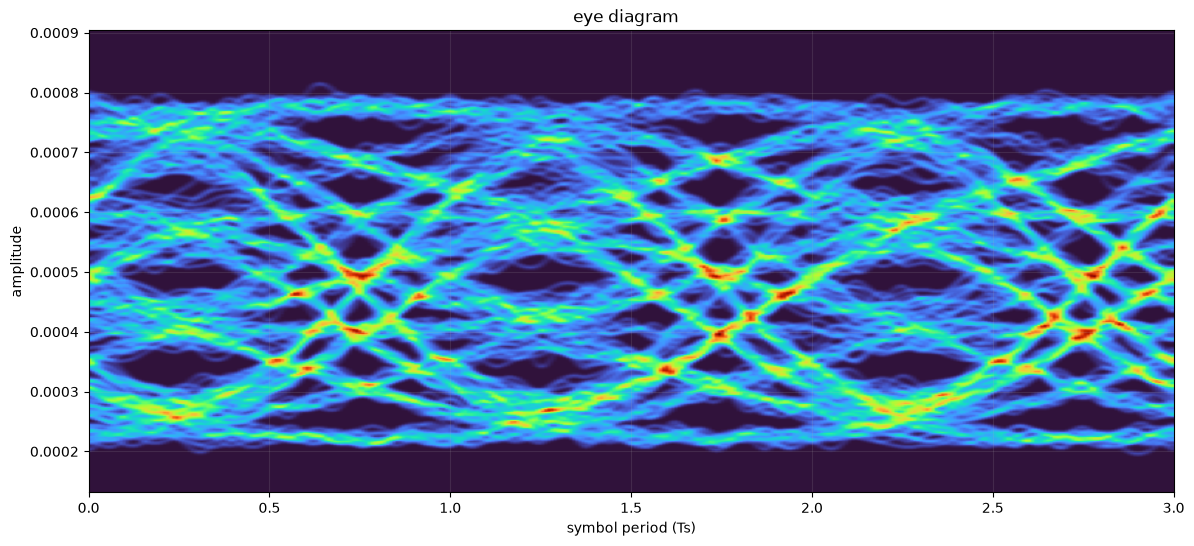

<function matplotlib.pyplot.show(close=None, block=None)>

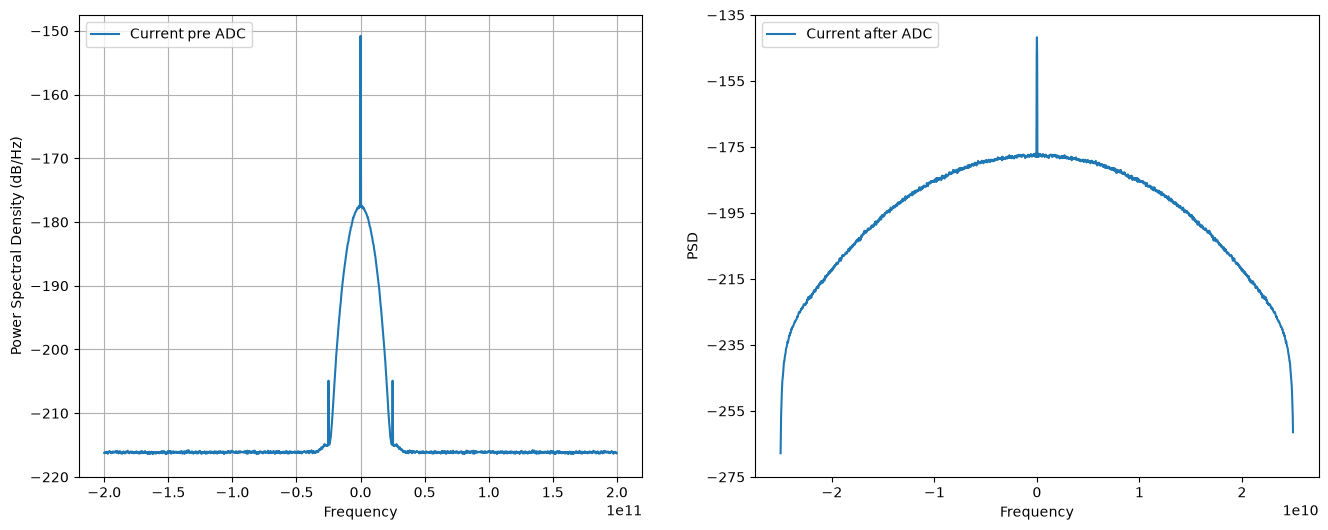

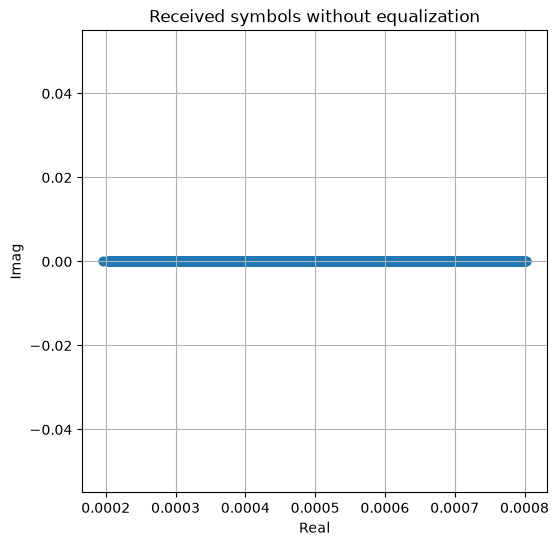

In [21]:
paramPD = parameters()
paramPD = parameters()
paramPD.R = 1.0                           # Responsividade de 1 A/W (Tabela I do artigo)
paramPD.Tc = 25                           # Não utilizado (o artigo fixa a PSD do ruído térmico)
paramPD.Id = 10e-9                             # Corrente de escuro zero (omitida no modelo matemático)
paramPD.Ipd_sat = 5e-3                    # Irrelevante (saturação desligada)
paramPD.RL = 50                           # Irrelevante (ruído térmico fixado externamente)
paramPD.B = 30e9                          # Irrelevante (limitação de banda desligada aqui)
paramPD.Fs = paramDAC.outFs               # Frequência de amostragem global da simulação
paramPD.fType = 'rect'                    # Irrelevante
paramPD.PDN = 255                         # Irrelevante
paramPD.ideal = False                     # False para permitir a injeção de ruídos
paramPD.shotNoise = True                  # O modelo do artigo analisa o Shot Noise
paramPD.thermalNoise = True               # O modelo do artigo analisa o Ruído Térmico
paramPD.currentSaturation = False         # O modelo assume um receptor estritamente linear
paramPD.bandwidthLimitation = False       # IMPORTANTE: Desligado (veja explicação abaixo)
paramPD.seed = 7                          # Qualquer número inteiro

PD_signalRx= photodiode(signal_optRx, paramPD)

eyediagram(np.real(PD_signalRx), len(PD_signalRx), n_dac*SpS ,ptype = 'fancy', plotlabel = "" \
"")
#plt.psd(PD_signalRx, NFFT = 1024, Fs = paramDAC.outFs, sides = 'twosided')

paramAdc = parameters()
paramAdc.inFs = paramDAC.outFs
paramAdc.outFs = Fs
paramAdc.Nbits = paramDAC.nBits
paramAdc.ENOB = paramDAC.ENOB
paramAdc.Vmax = np.max(np.abs(PD_signalRx))
paramAdc.Vmin = -paramAdc.Vmax
paramAdc.AAF = False

sigRx = adc(PD_signalRx, paramAdc)
sigRx = firFilter(pulse, sigRx)

fig, axs = plt.subplots(1, 2, figsize=(16,6))
# plot psd
axs[0].psd(PD_signalRx, Fs=paramDAC.outFs, NFFT = 2048, sides='twosided', label = 'Current pre ADC')
axs[0].legend(loc='upper left');

axs[1].psd(sigRx, Fs = Fs, NFFT = 2048, sides = 'twosided', label = "Current after ADC")
axs[1].set_ylabel('PSD')
axs[1].set_xlabel('Frequency')
axs[1].legend(loc='upper left')
axs[1].grid()
plt.rcParams['figure.figsize'] = (14, 6)

paramDec = parameters()
paramDec.SpSin = SpS
paramDec.SpSout = 1

symbRx_vis = decimate(sigRx, paramDec)

plt.figure(figsize=(6,6))
plt.scatter(np.real(symbRx_vis), np.imag(symbRx_vis))

plt.title("Received symbols without equalization")
plt.xlabel("Real")
plt.ylabel("Imag")
plt.grid(True)
plt.show





Performance results:
------------------------------------
Method      |  BER       |  SNR (dB)
------------------------------------
FFE         |  0.00e+00  |  22.43 
DFE         |  0.00e+00  |  22.95 


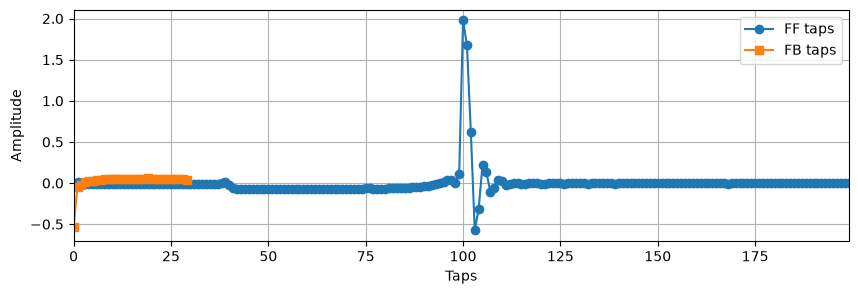

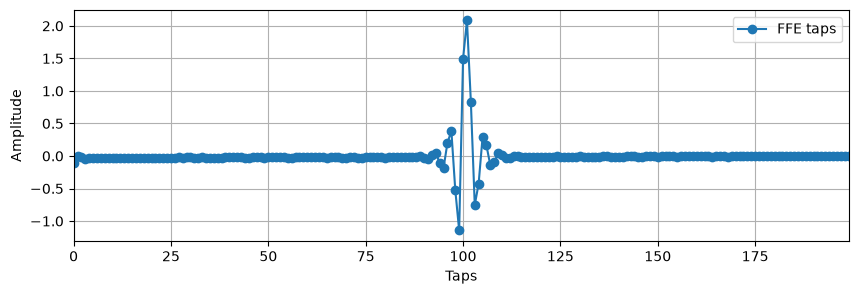

In [22]:
nTrain = 100000  # number of training symbols
plots = True  # enable/disable plots of equalizer taps and MSE convergence
trainingMode = "fulltime"

# Apply DFE equalization
paramDFE = parameters()
paramDFE.nTapsFF = 200
paramDFE.nTapsFB = 30
paramDFE.SpS = SpS
paramDFE.mu = 2e-3
paramDFE.nTrain = nTrain
paramDFE.M = M
paramDFE.trainingMode = trainingMode

outDFE, f, b, mseDFE = dfe(sigRx, symb_Tx, paramDFE)
outDFE = pnorm(outDFE)

if plots:
    plt.figure(figsize=(10,3))
    plt.plot(f, 'o-', label='FF taps')
    plt.plot(b, 's-', label='FB taps')
    plt.xlim(0, max(len(f), len(b))-1)
    plt.xlabel('Taps')
    plt.ylabel('Amplitude')
    plt.grid()
    plt.legend()

# Apply FFE equalization
paramFFE = parameters()
paramFFE.nTaps = 200
paramFFE.mu = 2e-3
paramFFE.nTrain = nTrain
paramFFE.SpS = SpS
paramFFE.M = M
paramFFE.trainingMode = trainingMode

outFFE, h, mseFFE = ffe(sigRx, symb_Tx, paramFFE)
#outFFE = pnorm(outFFE)

if plots:
    plt.figure(figsize=(10,3))
    plt.plot(h, 'o-', label='FFE taps')
    plt.legend()
    plt.xlim(0, len(h)-1)
    plt.xlabel('Taps')
    plt.ylabel('Amplitude')
    plt.grid()

discard = nTrain

# with FFE equalization
ber_ffe, ser_ffe, snr_ffe = fastBERcalc(outFFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')

# with DFE equalization
ber_dfe, ser_dfe, snr_dfe = fastBERcalc(outDFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')

print('Performance results:')
print('------------------------------------')
print('Method      |  BER       |  SNR (dB)')
print('------------------------------------')
print(f'FFE         |  {ber_ffe[0]:.2e}  |  {snr_ffe[0]:.2f} ')
print(f'DFE         |  {ber_dfe[0]:.2e}  |  {snr_dfe[0]:.2f} ') 

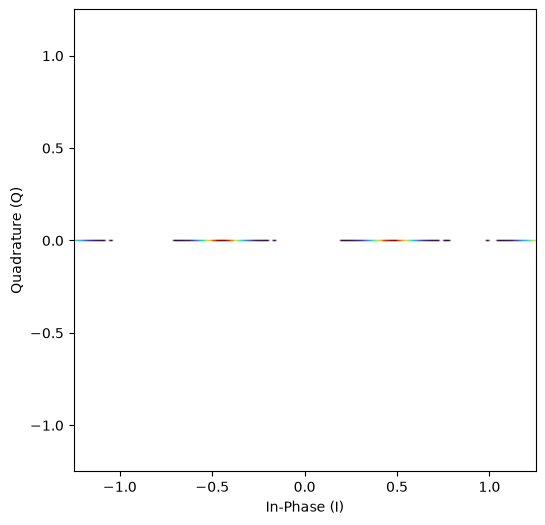

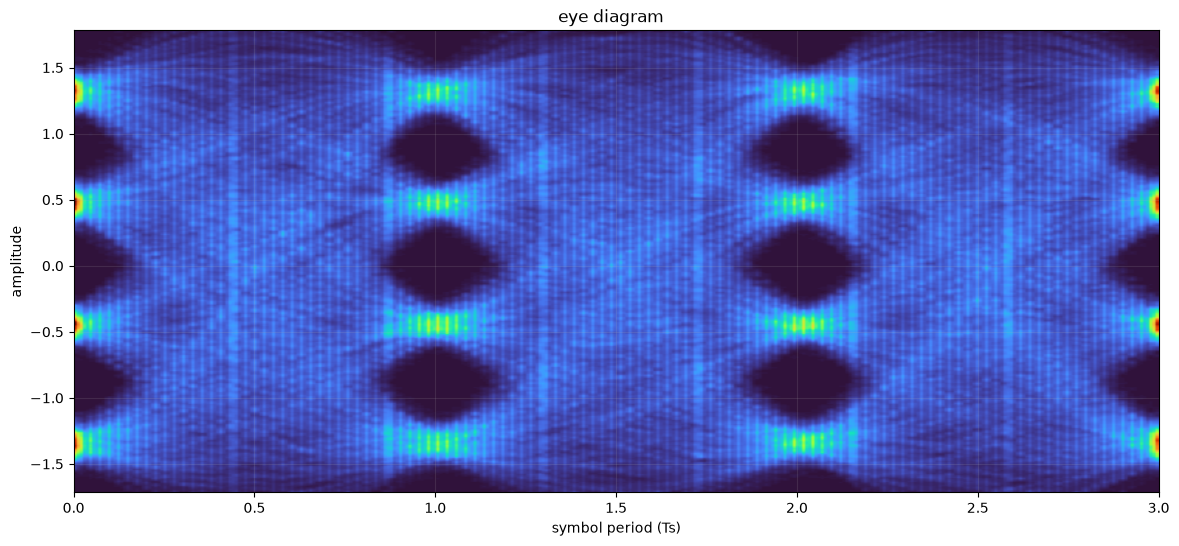

In [23]:
pconst(outFFE[discard:-discard])
eyediagram(outFFE[discard:-discard], len(outFFE)-2*discard, 1, 3, 'fancy')

Potência de Transmissão: 0.001 W
OMA Outer: 0.001 W
OMA Outer (dBm): 0.781 dBm


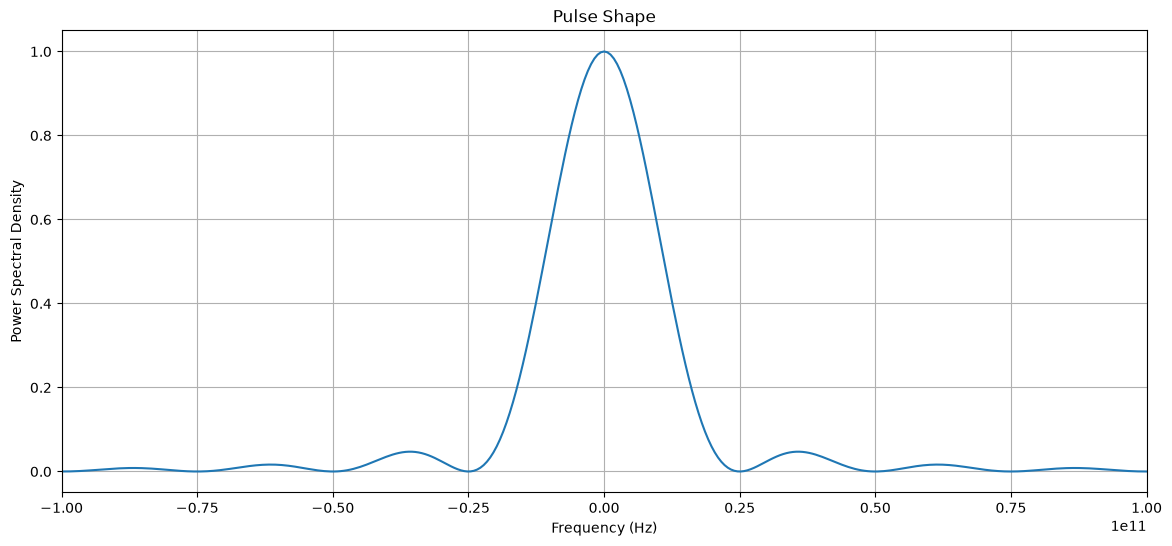

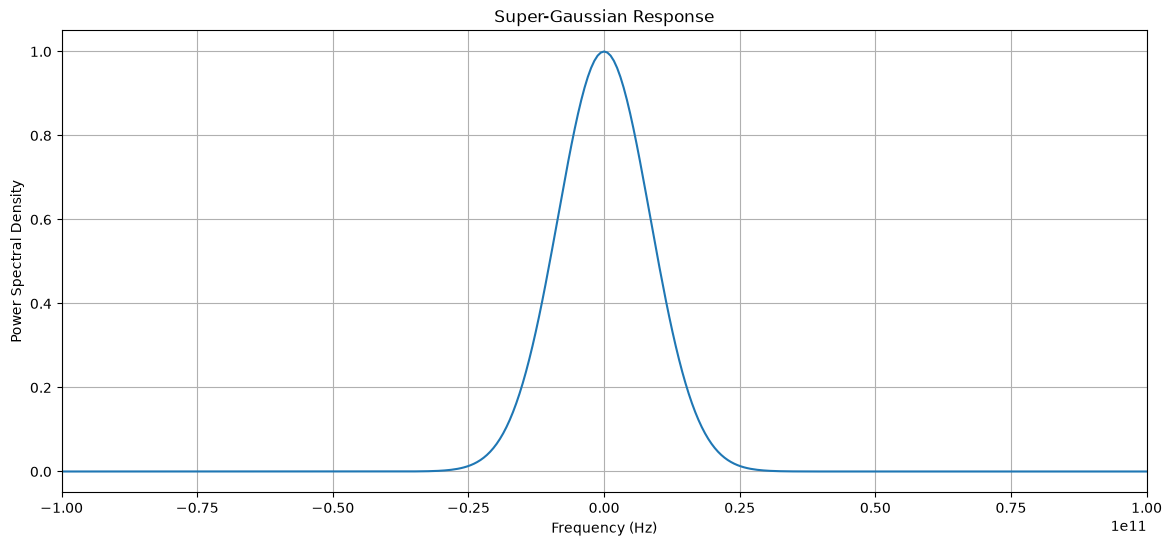

NameError: name 'calc_S_N_temp' is not defined

In [24]:
Rs = 25e9
pTx_dBm = 0
pTx_W = dBm2W(pTx_dBm)
print(f"Potência de Transmissão: {pTx_W:.3f} W")
ER = 10**(6/10)
OMA = 0.78
R = 1
N0 = 2e-19
RIN = -140
M = 4
Tb = 1/(Rs*2)

SIM_N = 10000        # Equivalente a SIM.N
SIM_fmax = 3e12      # Equivalente a SIM.fmax
TX_Ts = 1 / 25e9     

f = np.linspace(-SIM_fmax, SIM_fmax, SIM_N + 1)

# 2. Equivalente a: f_int = linspace(-1/(2*TX.Ts), 1/(2*TX.Ts), SIM.N)
# Aqui usamos o Nyquist para definir a banda de integração da fórmula de Fischer
f_int = np.linspace(-1 / (2 * TX_Ts), 1 / (2 * TX_Ts), SIM_N)
OMA_outer = 2*pTx_W*((ER-1)/(ER+1))
OMA_Outer_dBm = 10*np.log10(OMA_outer/1e-3)
print(f"OMA Outer: {OMA_outer:.3f} W")
print(f"OMA Outer (dBm): {OMA_Outer_dBm:.3f} dBm")

niveis_pam = np.linspace(-1, 1, M)
Ps2 = pTx_W + niveis_pam * (OMA_outer / 2)
pTx_mean_squared = np.mean(Ps2**2)

Pulse = np.sinc(2 * Tb * f)
plt.plot(f, np.abs(Pulse)**2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('Pulse Shape')
plt.grid(True)
plt.xlim(-1e11, 1e11)
plt.show()

superGauss_response = superGauss(f, n=1, B_3dB=0.4*Rs)
plt.plot(f, np.abs(superGauss_response)**2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('Super-Gaussian Response')
plt.grid(True)
plt.xlim(-1e11, 1e11)
plt.show()

S_RIN = calc_S_RIN(pTx_mean_squared, RIN, f)
S_th = calc_S_th(N0, f)
S_shot = calc_S_shot(pTx_W, R, 1, 1, f)

SuperGauss_response = superGauss(f, n=1, B_3dB=0.4*Rs)
superGaussSquared = np.abs(SuperGauss_response)**2

S_N_total = calc_S_N_temp(S_RIN, S_shot, S_th, superGaussSquared)
S_N_f = get_spectral_snr(f, OMA_outer, Rs, Pulse, SuperGauss_response, S_N_total)
SNR_folded = SNR_Folding(S_N_f, f, mu=2, Rs=Rs)

SNR_folded_dB = 10 * np.log10(np.abs(SNR_folded))
SNR_f_interp_dB = np.interp(f_int, f, SNR_folded_dB)
SNR_f_Nyquist = 10**(SNR_f_interp_dB / 10)  # Volta para escala linear

# 7. Integrais de Fischer (FFE / DFE) usando np.trapezoid
# FFE
SNR_int_ffe = np.trapezoid(1 / (SNR_f_Nyquist + 1), x=f_int)
SNR_FFE_dB = 10 * np.log10(1 / (TX_Ts * SNR_int_ffe) - 1)
SNR_FFE_linear = 10**(SNR_FFE_dB / 10)

# DFE
SNR_int_dfe = np.trapezoid(np.log(SNR_f_Nyquist + 1), x=f_int)
SNR_DFE_dB = 10 * np.log10(np.exp(TX_Ts * SNR_int_dfe) - 1)
SNR_DFE_linear = 10**(SNR_DFE_dB / 10)

# 8. Estimativa Global de BER (Para fins de comparação rápida)
BER_FFE_global = ber_from_snr_m_pam(SNR_FFE_linear, M)
BER_DFE_global = ber_from_snr_m_pam(SNR_DFE_linear, M)

print(f"SNR FFE: {SNR_FFE_dB:.2f} dB | BER FFE: {BER_FFE_global:.3e}")
print(f"SNR DFE: {SNR_DFE_dB:.2f} dB | BER DFE: {BER_DFE_global:.3e}")



Iniciando varredura analítica. Isso pode levar alguns segundos...


C:\Users\elmer.farias\AppData\Local\Temp\ipykernel_37496\3093841131.py:71: RuntimeWarning: divide by zero encountered in log10
  SNR_f_interp = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded))) / 10)
C:\Users\elmer.farias\AppData\Local\Temp\ipykernel_37496\3093841131.py:94: RuntimeWarning: divide by zero encountered in log10
  SNR_f_interp_eye = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded_eye))) / 10)


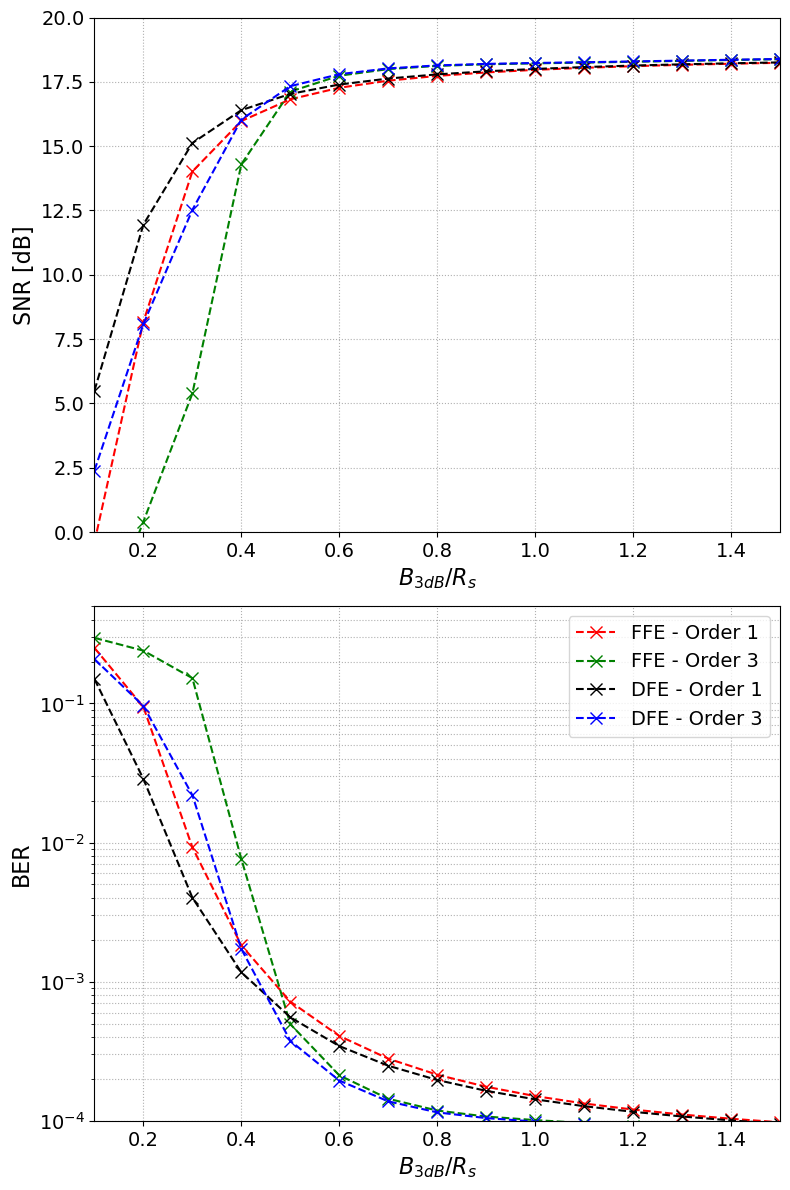

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. PARÂMETROS GLOBAIS E CONSTANTES
# =================================================================
Rs = 25e9
pTx_dBm = 0
pTx_W = 10**(pTx_dBm/10) * 1e-3
ER = 10**(6/10)
R = 1.0
N0 = 2e-19
RIN = -140
M = 4
Tb = 1 / (Rs * 2)
TX_Ts = 1 / Rs

SIM_N = 10000        
SIM_fmax = 3e12      

# Eixos de frequência
f = np.linspace(-SIM_fmax, SIM_fmax, SIM_N + 1)
f_int = np.linspace(-1 / (2 * TX_Ts), 1 / (2 * TX_Ts), SIM_N)

# Cálculo da OMA e Níveis do PAM-4
OMA_outer = 2 * pTx_W * ((ER - 1) / (ER + 1))
niveis_pam = np.linspace(-1, 1, M)
Ps2 = pTx_W + niveis_pam * (OMA_outer / 2)
pTx_mean_squared = np.mean(Ps2**2)

# Resposta do Pulso e Ruídos Fixos (Não dependem do filtro do canal)
Pulse = np.sinc(2 * Tb * f)
S_th = calc_S_th(N0, f)
S_shot = calc_S_shot(pTx_W, R, 1, 1, f) # Assumindo PIN sem ganho extra

# =================================================================
# 2. PREPARAÇÃO DOS LOOPS (VARREDURA)
# =================================================================
b_rs_ratios = np.arange(0.1, 1.6, 0.1) # Vai de 0.1 até 1.5
orders = [1, 3]

# Dicionários para armazenar os resultados para cada ordem
results = {
    1: {'snr_ffe': [], 'snr_dfe': [], 'ber_ffe': [], 'ber_dfe': []},
    3: {'snr_ffe': [], 'snr_dfe': [], 'ber_ffe': [], 'ber_dfe': []}
}

print("Iniciando varredura analítica. Isso pode levar alguns segundos...")

# =================================================================
# 3. LOOP PRINCIPAL
# =================================================================
for n in orders:
    for ratio in b_rs_ratios:
        B_3dB = ratio * Rs
        
        # 1. Resposta do Canal
        H_ch = superGauss(f, n=n, B_3dB=B_3dB)
        H_ch_sq = np.abs(H_ch)**2
        
        # 2. Ruído Total Global (Para plotar a curva de SNR Global)
        S_RIN_global = calc_S_RIN(pTx_mean_squared, RIN, f)
        S_N_total = calc_S_N_temp(S_RIN_global, S_shot, S_th, H_ch_sq)
        
        # 3. SNR Espectral (Global)
        S_N_f = get_spectral_snr(f, OMA_outer, Rs, Pulse, H_ch, S_N_total)
        S_N_f = np.nan_to_num(S_N_f, nan=0.0)
        
        # 4. Folding e Integrais Globais (Para o Gráfico de SNR)
        SNR_folded = SNR_Folding(S_N_f, f, mu=2, Rs=Rs)
        SNR_f_interp = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded))) / 10)
        
        snr_ffe_lin = 1 / (TX_Ts * np.trapezoid(1 / (SNR_f_interp + 1), x=f_int)) - 1
        snr_dfe_lin = np.exp(TX_Ts * np.trapezoid(np.log(SNR_f_interp + 1), x=f_int)) - 1
        
        results[n]['snr_ffe'].append(10 * np.log10(snr_ffe_lin))
        results[n]['snr_dfe'].append(10 * np.log10(snr_dfe_lin))
        
        # 5. Loop Heurístico "Olho-por-Olho" (Para o Gráfico de BER)
        ber_ffe_eyes = []
        ber_dfe_eyes = []
        
        for i in range(M - 1):
            # Recalcula o RIN focado na potência dos 2 níveis que formam ESTE olho
            pTx_eye_squared = np.mean(Ps2[i : i+2]**2)
            S_RIN_eye = calc_S_RIN(pTx_eye_squared, RIN, f)
            S_N_eye = calc_S_N_temp(S_RIN_eye, S_shot, S_th, H_ch_sq)
            
            # SNR e Folding deste olho
            S_N_f_eye = get_spectral_snr(f, OMA_outer, Rs, Pulse, H_ch, S_N_eye)
            S_N_f_eye = np.nan_to_num(S_N_f_eye, nan=0.0)
            
            SNR_folded_eye = SNR_Folding(S_N_f_eye, f, mu=2, Rs=Rs)
            SNR_f_interp_eye = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded_eye))) / 10)
            
            # Equalizadores
            snr_ffe_eye_lin = 1 / (TX_Ts * np.trapezoid(1 / (SNR_f_interp_eye + 1), x=f_int)) - 1
            snr_dfe_eye_lin = np.exp(TX_Ts * np.trapezoid(np.log(SNR_f_interp_eye + 1), x=f_int)) - 1
            
            ber_ffe_eyes.append(ber_from_snr_m_pam(snr_ffe_eye_lin, M))
            ber_dfe_eyes.append(ber_from_snr_m_pam(snr_dfe_eye_lin, M))
            
        # A BER final é a média das BERs dos 3 olhos
        results[n]['ber_ffe'].append(np.mean(ber_ffe_eyes))
        results[n]['ber_dfe'].append(np.mean(ber_dfe_eyes))

# =================================================================
# 4. PLOTAGEM DOS GRÁFICOS (Idêntico ao Artigo)
# =================================================================
fig, axs = plt.subplots(2, 1, figsize=(8, 12))

# Gráfico 1: SNR
axs[0].plot(b_rs_ratios, results[1]['snr_ffe'], 'r--x', label='FFE - Order 1', markersize=8)
axs[0].plot(b_rs_ratios, results[3]['snr_ffe'], 'g--x', label='FFE - Order 3', markersize=8)
axs[0].plot(b_rs_ratios, results[1]['snr_dfe'], 'k--x', label='DFE - Order 1', markersize=8)
axs[0].plot(b_rs_ratios, results[3]['snr_dfe'], 'b--x', label='DFE - Order 3', markersize=8)
axs[0].set_xlabel(r'$B_{3dB}/R_s$', fontsize=16)
axs[0].set_ylabel('SNR [dB]', fontsize=16)
axs[0].set_ylim(0, 20)
axs[0].set_xlim(0.1, 1.5)
axs[0].grid(True, linestyle=':')
axs[0].tick_params(axis='both', labelsize=14)

# Gráfico 2: BER
axs[1].semilogy(b_rs_ratios, results[1]['ber_ffe'], 'r--x', label='FFE - Order 1', markersize=8)
axs[1].semilogy(b_rs_ratios, results[3]['ber_ffe'], 'g--x', label='FFE - Order 3', markersize=8)
axs[1].semilogy(b_rs_ratios, results[1]['ber_dfe'], 'k--x', label='DFE - Order 1', markersize=8)
axs[1].semilogy(b_rs_ratios, results[3]['ber_dfe'], 'b--x', label='DFE - Order 3', markersize=8)
axs[1].set_xlabel(r'$B_{3dB}/R_s$', fontsize=16)
axs[1].set_ylabel('BER', fontsize=16)
axs[1].set_ylim(7e-5, 0.5)
axs[1].set_xlim(0.1, 1.5)
axs[1].grid(True, linestyle=':', which='both')
axs[1].tick_params(axis='both', labelsize=14)
axs[1].legend(fontsize=14, loc='upper right')

plt.tight_layout()
plt.show()

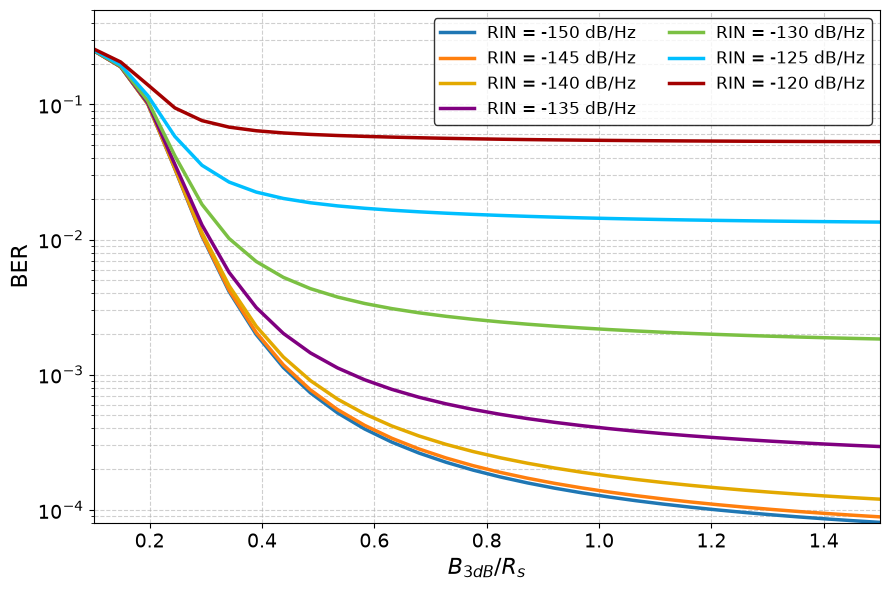

In [ ]:

q = 1.602176634e-19 # Carga do elétron

# --- Parâmetros da Figura 4(b) do artigo ---
Rs = 56e9             # Taxa de símbolos: 56 GBaud
P_TX_dBm = 0          # Potência de transmissão: 0 dBm
P_TX_W = 1e-3         # Potência em Watts (1 mW)
ER_dB = 12            # Razão de extinção: 12 dB
N0 = 2e-19            # Ruído térmico [W^2/Hz] (Tabela I)
R_resp = 1.0          # Responsividade [A/W] (Tabela I)
M = 4                 # 4-PAM
n_sg = 1              # Filtro Supergaussiano de ordem 1
mu = 2                # Número de dobramentos do espectro (aliasing)

# Eixo X e variação do RIN
ratio_B_Rs = np.linspace(0.1, 1.5, 30)
RIN_list = [-150, -145, -140, -135, -130, -125, -120]

# Vetor de frequências (Banda larga o suficiente para capturar o ruído antes do folding)
f = np.linspace(-4 * Rs, 4 * Rs, 4096)
df = f[1] - f[0]

# Filtro de formatação do pulso do transmissor (Retangular no tempo -> Sinc na frequência)
# np.sinc(x) em Python calcula sin(pi*x)/(pi*x)
H_T = np.sinc(f / Rs)

# --- Cálculo dos Níveis de Potência (Heurística do Artigo) ---
# Encontrar as potências exatas dos 4 níveis do PAM para isolar os 3 olhos
ER_lin = 10**(ER_dB / 10)
P0_W = (2 * P_TX_W) / (ER_lin + 1)
P3_W = P0_W * ER_lin
OMA_W = P3_W - P0_W

# Os 4 níveis do PAM
P1_W = P0_W + OMA_W / 3
P2_W = P0_W + 2 * OMA_W / 3

# Potência Média de cada um dos 3 olhos internos
P_eye_1 = (P0_W + P1_W) / 2
P_eye_2 = (P1_W + P2_W) / 2
P_eye_3 = (P2_W + P3_W) / 2
P_eyes = [P_eye_1, P_eye_2, P_eye_3]

# Dicionário para guardar as BERs
ber_results = {rin: [] for rin in RIN_list}

# --- Loop Principal de Cálculo Analítico ---
for rin in RIN_list:
    for ratio in ratio_B_Rs:
        B_3dB = ratio * Rs
        H_ch = superGauss(f, n_sg, B_3dB)
        H_ch_sq = np.abs(H_ch)**2
        
        ber_eyes_temp = []
        
        # Iterar sobre cada olho aplicando ruídos independentes baseados em suas potências
        for P_eye in P_eyes:
            # Densidades espectrais de ruído
            S_th = np.full_like(f, N0 / 2)
            # Shot noise (G=1, F=1 para fotodiodo PIN)
            S_shot = np.full_like(f, q * P_eye * R_resp)
            # RIN
            RIN_lin = 10**(rin / 10)
            S_RIN_scalar = (RIN_lin / 2) * (P_eye**2)
            
            # Ruído total
            S_N = calc_S_N(S_RIN_scalar, S_shot, S_th, H_ch_sq)
            
            # Calcular SNR Espectral
            # OMA é passado em Watts para manter a consistência matemática com S_N em W^2/Hz
            snr_f = get_spectral_snr(f, OMA_W, Rs, H_T, H_ch, S_N)
            
            # Dobramento de espectro (Aliasing do ADC)
            snr_folded = SNR_Folding(snr_f, f, mu, Rs)
            
            # Integração analítica FFE
            snr_ffe = SNR_FFE(snr_folded, f, Rs)
            
            # Estimar BER para este olho específico
            ber_eye = ber_from_snr_m_pam(snr_ffe, M)
            ber_eyes_temp.append(ber_eye)
            
        # A BER global é a média das BERs dos 3 olhos (Equação da Seção II do artigo)
        avg_ber = np.mean(ber_eyes_temp)
        ber_results[rin].append(avg_ber)

# --- Plotagem do Gráfico ---
plt.figure(figsize=(9, 6))

# Paleta de cores para se assemelhar com as curvas do artigo
colors = ['#1f77b4', '#ff7f0e', '#e3a900', '#800080', '#7bc043', '#00bfff', '#a30000']

for i, rin in enumerate(RIN_list):
    plt.semilogy(ratio_B_Rs, ber_results[rin], label=f'RIN = {rin} dB/Hz', 
                 color=colors[i], linewidth=2.5)

plt.xlabel(r'$B_{3dB}/R_s$', fontsize=16)
plt.ylabel('BER', fontsize=16)

# Configurações para idêntica visualização do artigo
plt.ylim(8e-5, 5e-1)
plt.xlim(0.1, 1.5)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend(ncol=2, fontsize=12, loc='upper right', edgecolor='black')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq

# Importações nativas do OptiCommPy
from optic.comm.sources import bitSource
from optic.comm.modulation import modulateGray
from optic.dsp.core import pulseShape, upsample, firFilter, pnorm
from optic.models.devices import photodiode
from optic.dsp.equalization import ffe, dfe
from optic.comm.metrics import fastBERcalc
from optic.utils import parameters

# =================================================================
# 1. PARÂMETROS GLOBAIS
# =================================================================
Rs = 25e9
SpS = 8
Fs = Rs * SpS
M = 4

# Parâmetros Ópticos (Tabela I)
P_TX_dBm = 0
P_TX_W = 10**(P_TX_dBm / 10) * 1e-3
ER_dB = 6
ER_lin = 10**(ER_dB / 10)
OMA_W = 2 * P_TX_W * (ER_lin - 1) / (ER_lin + 1)
P0 = P_TX_W - OMA_W/2

# =================================================================
# 2. TRANSMISSOR (Usando OptiCommPy Nativo)
# =================================================================
# Geração de Bits
paramBits = parameters()
paramBits.nBits = int(100000 * np.log2(M))
paramBits.mode = 'random'
paramBits.seed = 123
bitsTx = bitSource(paramBits)

# Modulação PAM-4 (Estes são os símbolos padronizados para o Equalizador!)
symbTx_norm = modulateGray(bitsTx, M, 'pam')
symbTx_norm = pnorm(symbTx_norm) 

# Mapeamento Físico: Transformando símbolos normalizados em Potência Óptica (Watts)
levels_norm = np.unique(symbTx_norm)
levels_watt = [P0, P0 + OMA_W/3, P0 + 2*OMA_W/3, P0 + OMA_W]

symbTx_W = np.zeros_like(symbTx_norm, dtype=float)
for i in range(M):
    symbTx_W[symbTx_norm == levels_norm[i]] = levels_watt[i]

# Upsampling e Formatação de Pulso (Retangular)
symbolsUp = upsample(symbTx_W, SpS)
paramPulse = parameters()
paramPulse.pulseType = 'nrz'
paramPulse.SpS = SpS
pulse = pulseShape(paramPulse)
sigTx_W = firFilter(pulse, symbolsUp)

# =================================================================
# 3. CANAL FÍSICO E RUÍDOS
# =================================================================
# 3.1 Adição do RIN (Direto na potência)
RIN = -140
rin_lin = 10**(RIN / 10)
var_rin = rin_lin * (sigTx_W**2) * (Fs / 2)
n_rin = np.random.normal(0, np.sqrt(np.maximum(var_rin, 0)))
sigTx_rin = sigTx_W + n_rin

# 3.2 Canal Supergaussiano (Limitação de Banda severa: B_3dB = 0.3 * Rs)
B_3dB = 0.3 * Rs
n_sg = 1
f_sim = fftfreq(len(sigTx_rin), 1/Fs)
H_ch_sim = np.exp(-(np.log(2)/2) * (f_sim / B_3dB)**(2*n_sg))
sigCh = np.real(ifft(fft(sigTx_rin) * H_ch_sim))

# Prevenção: O ringing do filtro pode gerar potências negativas irrealistas.
sigCh_opt = np.maximum(sigCh, 0) 

# 3.3 Fotodiodo
paramPD = parameters()
paramPD.R = 1.0
paramPD.ideal = False
paramPD.shotNoise = True
paramPD.thermalNoise = True
paramPD.B = Fs / 2       # CORREÇÃO AQUI: Nyquist exige que B seja no máximo Fs/2
paramPD.Fs = Fs
paramPD.seed = 456

I_Rx = photodiode(sigCh_opt, paramPD)
I_Rx = photodiode(sigCh_opt, paramPD)

# =================================================================
# 4. DSP NO RECEPTOR (EQUALIZAÇÃO E BER)
# =================================================================
# CORREÇÃO CRÍTICA AQUI: Remover a corrente contínua (DC bias) da luz
I_Rx_ac = I_Rx - np.mean(I_Rx)
I_Rx_norm = pnorm(I_Rx_ac)  # Agora sim enviamos para o LMS!

nTrain = 80000 
discard = nTrain

# (O resto da equalização FFE e DFE continua idêntico, 
# mas não esqueça de usar I_Rx_norm no ffe() e dfe() )

# Equalização FFE
paramFFE = parameters()
paramFFE.nTaps = 151
paramFFE.mu = 1e-3
paramFFE.nTrain = nTrain
paramFFE.SpS = SpS
paramFFE.M = M
paramFFE.trainingMode = "fulltime"

outFFE, h, mseFFE = ffe(I_Rx_norm, symbTx_norm, paramFFE)

# Ajuste automático de dimensão para o fastBERcalc
dec_ffe = len(outFFE) // len(symbTx_norm)
outFFE_1sps = outFFE[::dec_ffe]
min_len_ffe = min(len(outFFE_1sps), len(symbTx_norm))

ber_ffe, ser_ffe, snr_ffe = fastBERcalc(
    outFFE_1sps[discard : min_len_ffe - discard//10], 
    symbTx_norm[discard : min_len_ffe - discard//10], 
    M, 'pam'
)

print('Resultados da Simulação OptiCommPy:')
print('------------------------------------')
print('Method      |  BER       |  SNR (dB)')
print('------------------------------------')
print(f'FFE         |  {ber_ffe[0]:.2e}  |  {snr_ffe[0]:.2f} ')

Resultados da Simulação OptiCommPy:
------------------------------------
Method      |  BER       |  SNR (dB)
------------------------------------
FFE         |  5.05e-01  |  -3.03 


In [ ]:

# (Assumindo que suas funções analíticas calc_S_RIN, calc_S_N_temp, SNR_Folding, etc., estão definidas aqui)

# =================================================================
# 1. PARÂMETROS GLOBAIS E CONSTANTES
# =================================================================
Rs = 25e9
SpS = 8
Fs = Rs * SpS
M = 4

pTx_dBm = 0
pTx_W = 10**(pTx_dBm/10) * 1e-3
ER = 10**(6/10)
R = 1.0
N0 = 2e-19
RIN = -140
Tb = 1 / (Rs * 2)
TX_Ts = 1 / Rs

# Eixos de frequência (Analítico)
SIM_N = 10000        
SIM_fmax = 3e12      
f = np.linspace(-SIM_fmax, SIM_fmax, SIM_N + 1)
f_int = np.linspace(-1 / (2 * TX_Ts), 1 / (2 * TX_Ts), SIM_N)

# Cálculo da OMA e Níveis do PAM-4
OMA_outer = 2 * pTx_W * ((ER - 1) / (ER + 1))
niveis_pam = np.linspace(-1, 1, M)
Ps2 = pTx_W + niveis_pam * (OMA_outer / 2)
pTx_mean_squared = np.mean(Ps2**2)
P0 = pTx_W - OMA_outer/2

# Resposta do Pulso e Ruídos Fixos (Analítico)
Pulse = np.sinc(2 * Tb * f)
S_th = calc_S_th(N0, f)
S_shot = calc_S_shot(pTx_W, R, 1, 1, f)

# =================================================================
# 2. PREPARAÇÃO DA SIMULAÇÃO TEMPORAL (FORA DO LOOP PARA VELOCIDADE)
# =================================================================
print("Gerando sinal transmitido para a simulação...")
paramBits = parameters()
paramBits.nBits = int(80000 * np.log2(M)) # Reduzido levemente para acelerar o loop duplo
paramBits.mode = 'random'
paramBits.seed = 123
bitsTx = bitSource(paramBits)

symbTx_norm = modulateGray(bitsTx, M, 'pam')
symbTx_norm = pnorm(symbTx_norm) 

levels_norm = np.unique(symbTx_norm)
levels_watt = [P0, P0 + OMA_outer/3, P0 + 2*OMA_outer/3, P0 + OMA_outer]
symbTx_W = np.zeros_like(symbTx_norm, dtype=float)
for i in range(M):
    symbTx_W[symbTx_norm == levels_norm[i]] = levels_watt[i]

symbolsUp = upsample(symbTx_W, SpS)
paramPulse = parameters()
paramPulse.pulseType = 'nrz'
paramPulse.SpS = SpS
pulse = pulseShape(paramPulse)
sigTx_W = firFilter(pulse, symbolsUp)

# =================================================================
# 3. PREPARAÇÃO DOS LOOPS (VARREDURA)
# =================================================================
b_rs_ratios = np.arange(0.1, 1.6, 0.1)
orders = [1, 3]

results_ana = {1: {'snr_ffe': [], 'snr_dfe': [], 'ber_ffe': [], 'ber_dfe': []},
               3: {'snr_ffe': [], 'snr_dfe': [], 'ber_ffe': [], 'ber_dfe': []}}

results_sim = {1: {'snr_ffe': [], 'snr_dfe': [], 'ber_ffe': [], 'ber_dfe': []},
               3: {'snr_ffe': [], 'snr_dfe': [], 'ber_ffe': [], 'ber_dfe': []}}

print("Iniciando varredura conjunta (Analítica + Simulação)...")

# =================================================================
# 4. LOOP PRINCIPAL
# =================================================================
for n in orders:
    for ratio in b_rs_ratios:
        B_3dB = ratio * Rs
        print(f"Processando Ordem={n}, B_3dB/Rs={ratio:.1f}...")
        
        # ---------------------------------------------------------
        # PARTE A: MODELO ANALÍTICO
        # ---------------------------------------------------------
        H_ch = superGauss(f, n=n, B_3dB=B_3dB)
        H_ch_sq = np.abs(H_ch)**2
        
        S_RIN_global = calc_S_RIN(pTx_mean_squared, RIN, f)
        S_N_total = calc_S_N_temp(S_RIN_global, S_shot, S_th, H_ch_sq)
        
        S_N_f = get_spectral_snr(f, OMA_outer, Rs, Pulse, H_ch, S_N_total)
        S_N_f = np.nan_to_num(S_N_f, nan=0.0)
        
        SNR_folded = SNR_Folding(S_N_f, f, mu=2, Rs=Rs)
        SNR_f_interp = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded))) / 10)
        
        snr_ffe_lin = 1 / (TX_Ts * np.trapezoid(1 / (SNR_f_interp + 1), x=f_int)) - 1
        snr_dfe_lin = np.exp(TX_Ts * np.trapezoid(np.log(SNR_f_interp + 1), x=f_int)) - 1
        
        results_ana[n]['snr_ffe'].append(10 * np.log10(snr_ffe_lin))
        results_ana[n]['snr_dfe'].append(10 * np.log10(snr_dfe_lin))
        
        ber_ffe_eyes, ber_dfe_eyes = [], []
        for i in range(M - 1):
            pTx_eye_squared = np.mean(Ps2[i : i+2]**2)
            S_RIN_eye = calc_S_RIN(pTx_eye_squared, RIN, f)
            S_N_eye = calc_S_N_temp(S_RIN_eye, S_shot, S_th, H_ch_sq)
            
            S_N_f_eye = get_spectral_snr(f, OMA_outer, Rs, Pulse, H_ch, S_N_eye)
            S_N_f_eye = np.nan_to_num(S_N_f_eye, nan=0.0)
            
            SNR_folded_eye = SNR_Folding(S_N_f_eye, f, mu=2, Rs=Rs)
            SNR_f_interp_eye = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded_eye))) / 10)
            
            snr_ffe_eye_lin = 1 / (TX_Ts * np.trapezoid(1 / (SNR_f_interp_eye + 1), x=f_int)) - 1
            snr_dfe_eye_lin = np.exp(TX_Ts * np.trapezoid(np.log(SNR_f_interp_eye + 1), x=f_int)) - 1
            
            ber_ffe_eyes.append(ber_from_snr_m_pam(snr_ffe_eye_lin, M))
            ber_dfe_eyes.append(ber_from_snr_m_pam(snr_dfe_eye_lin, M))
            
        results_ana[n]['ber_ffe'].append(np.mean(ber_ffe_eyes))
        results_ana[n]['ber_dfe'].append(np.mean(ber_dfe_eyes))

        # ---------------------------------------------------------
        # PARTE B: SIMULAÇÃO TEMPORAL
        # ---------------------------------------------------------
        # Adição do RIN
        rin_lin = 10**(RIN / 10)
        var_rin = rin_lin * (sigTx_W**2) * (Fs / 2)
        n_rin = np.random.normal(0, np.sqrt(np.maximum(var_rin, 0)))
        sigTx_rin = sigTx_W + n_rin

        # Filtro H_ch
        f_sim = fftfreq(len(sigTx_rin), 1/Fs)
        H_ch_sim = np.exp(-(np.log(2)/2) * (f_sim / B_3dB)**(2*n))
        sigCh = np.real(ifft(fft(sigTx_rin) * H_ch_sim))
        sigCh_opt = np.maximum(sigCh, 0) 

        # Fotodiodo
        paramPD = parameters()
        paramPD.R = 1.0
        paramPD.ideal = False
        paramPD.shotNoise = True
        paramPD.thermalNoise = True
        paramPD.B = Fs / 2 
        paramPD.Fs = Fs
        paramPD.seed = 456
        I_Rx = photodiode(sigCh_opt, paramPD)

        # Preparação do Sinal (Remoção DC e Normalização)
        I_Rx_ac = I_Rx - np.mean(I_Rx)
        I_Rx_norm = pnorm(I_Rx_ac)

        nTrain = 60000 
        discard = nTrain

        # FFE
        paramFFE = parameters()
        paramFFE.nTaps = 51 # Reduzido para agilizar varredura
        paramFFE.mu = 1e-3
        paramFFE.nTrain = nTrain
        paramFFE.SpS = SpS
        paramFFE.M = M
        paramFFE.trainingMode = "fulltime"
        outFFE, _, _ = ffe(I_Rx_norm, symbTx_norm, paramFFE)

        # DFE
        paramDFE = parameters()
        paramDFE.nTapsFF = 51
        paramDFE.nTapsFB = 15
        paramDFE.SpS = SpS
        paramDFE.mu = 1e-3
        paramDFE.nTrain = nTrain
        paramDFE.M = M
        paramDFE.trainingMode = "fulltime"
        outDFE, _, _, _ = dfe(I_Rx_norm, symbTx_norm, paramDFE)

        # Cálculo de Desempenho
        dec_ffe = len(outFFE) // len(symbTx_norm)
        dec_dfe = len(outDFE) // len(symbTx_norm)
        
        outFFE_1sps = outFFE[::dec_ffe]
        outDFE_1sps = outDFE[::dec_dfe]
        
        min_len_ffe = min(len(outFFE_1sps), len(symbTx_norm))
        min_len_dfe = min(len(outDFE_1sps), len(symbTx_norm))
        
        ber_sim_ffe, _, snr_sim_ffe = fastBERcalc(
            outFFE_1sps[discard : min_len_ffe - discard//10], 
            symbTx_norm[discard : min_len_ffe - discard//10], M, 'pam')
            
        ber_sim_dfe, _, snr_sim_dfe = fastBERcalc(
            outDFE_1sps[discard : min_len_dfe - discard//10], 
            symbTx_norm[discard : min_len_dfe - discard//10], M, 'pam')
            
        results_sim[n]['snr_ffe'].append(snr_sim_ffe[0])
        results_sim[n]['snr_dfe'].append(snr_sim_dfe[0])
        results_sim[n]['ber_ffe'].append(ber_sim_ffe[0])
        results_sim[n]['ber_dfe'].append(ber_sim_dfe[0])

# =================================================================
# 5. PLOTAGEM DOS GRÁFICOS (Analítico vs Simulação)
# =================================================================
fig, axs = plt.subplots(2, 1, figsize=(9, 12))

# Gráfico 1: SNR
axs[0].plot(b_rs_ratios, results_ana[1]['snr_ffe'], 'r--x', label='Ana FFE (n=1)', markersize=7)
axs[0].plot(b_rs_ratios, results_ana[3]['snr_ffe'], 'g--x', label='Ana FFE (n=3)', markersize=7)
axs[0].plot(b_rs_ratios, results_ana[1]['snr_dfe'], 'k--x', label='Ana DFE (n=1)', markersize=7)
axs[0].plot(b_rs_ratios, results_ana[3]['snr_dfe'], 'b--x', label='Ana DFE (n=3)', markersize=7)

axs[0].plot(b_rs_ratios, results_sim[1]['snr_ffe'], 'r-s', label='Sim FFE (n=1)', alpha=0.7)
axs[0].plot(b_rs_ratios, results_sim[3]['snr_ffe'], 'g-s', label='Sim FFE (n=3)', alpha=0.7)
axs[0].plot(b_rs_ratios, results_sim[1]['snr_dfe'], 'k-s', label='Sim DFE (n=1)', alpha=0.7)
axs[0].plot(b_rs_ratios, results_sim[3]['snr_dfe'], 'b-s', label='Sim DFE (n=3)', alpha=0.7)

axs[0].set_xlabel(r'$B_{3dB}/R_s$', fontsize=14)
axs[0].set_ylabel('SNR [dB]', fontsize=14)
axs[0].set_xlim(0.1, 1.5)
axs[0].grid(True, linestyle=':')
axs[0].legend(ncol=2, fontsize=10, loc='lower right')
axs[0].set_title('Validação da Relação Sinal-Ruído (SNR)')

# Gráfico 2: BER
axs[1].semilogy(b_rs_ratios, results_ana[1]['ber_ffe'], 'r--x', label='Ana FFE (n=1)')
axs[1].semilogy(b_rs_ratios, results_ana[3]['ber_ffe'], 'g--x', label='Ana FFE (n=3)')
axs[1].semilogy(b_rs_ratios, results_ana[1]['ber_dfe'], 'k--x', label='Ana DFE (n=1)')
axs[1].semilogy(b_rs_ratios, results_ana[3]['ber_dfe'], 'b--x', label='Ana DFE (n=3)')

axs[1].semilogy(b_rs_ratios, results_sim[1]['ber_ffe'], 'r-s', label='Sim FFE (n=1)', alpha=0.7)
axs[1].semilogy(b_rs_ratios, results_sim[3]['ber_ffe'], 'g-s', label='Sim FFE (n=3)', alpha=0.7)
axs[1].semilogy(b_rs_ratios, results_sim[1]['ber_dfe'], 'k-s', label='Sim DFE (n=1)', alpha=0.7)
axs[1].semilogy(b_rs_ratios, results_sim[3]['ber_dfe'], 'b-s', label='Sim DFE (n=3)', alpha=0.7)

axs[1].set_xlabel(r'$B_{3dB}/R_s$', fontsize=14)
axs[1].set_ylabel('BER', fontsize=14)
axs[1].set_ylim(7e-5, 0.5)
axs[1].set_xlim(0.1, 1.5)
axs[1].grid(True, linestyle=':', which='both')
axs[1].legend(ncol=2, fontsize=10, loc='upper right')
axs[1].set_title('Validação da Taxa de Erro de Bit (BER)')

plt.tight_layout()
plt.show()

NameError: name 'calc_S_th' is not defined